# Synthetic Circles v3 — Generate & Upload

Differences from v2:
- **Noisy background**: Gaussian noise (std sampled uniformly in `[NOISE_STD_MIN, NOISE_STD_MAX]` per image) instead of white background
- **Same seed (13), same circle geometry**
- HF repo: `Bmingg/cs280-synthetic-circles-v3`

Dataset columns: `image`, `cx`, `cy`, `radius`, `color` (0=red, 1=green, 2=blue)

In [1]:
import json
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image as PILImage
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

SEED       = 13
IMAGE_SIZE = 384
PATCH_SIZE = 16
PATCH_GRID = IMAGE_SIZE // PATCH_SIZE   # 24
EMBED_DIM  = 1408

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Noise level for the background (Gaussian std, values in [0,1])
NOISE_STD_MIN = 0.05
NOISE_STD_MAX = 0.20

# color index → RGB float
COLORS = {
    0: [1.0, 0.0, 0.0],   # red
    1: [0.0, 1.0, 0.0],   # green
    2: [0.0, 0.0, 1.0],   # blue
}
COLOR_NAMES = {0: 'red', 1: 'green', 2: 'blue'}

DATASET_DIR = Path('../data/processed/decoder_dataset_v3')
print(f'Seed={SEED}, image_size={IMAGE_SIZE}, noise_std=[{NOISE_STD_MIN}, {NOISE_STD_MAX}]')

Seed=13, image_size=384, noise_std=[0.05, 0.2]


## 1. Dataset Class

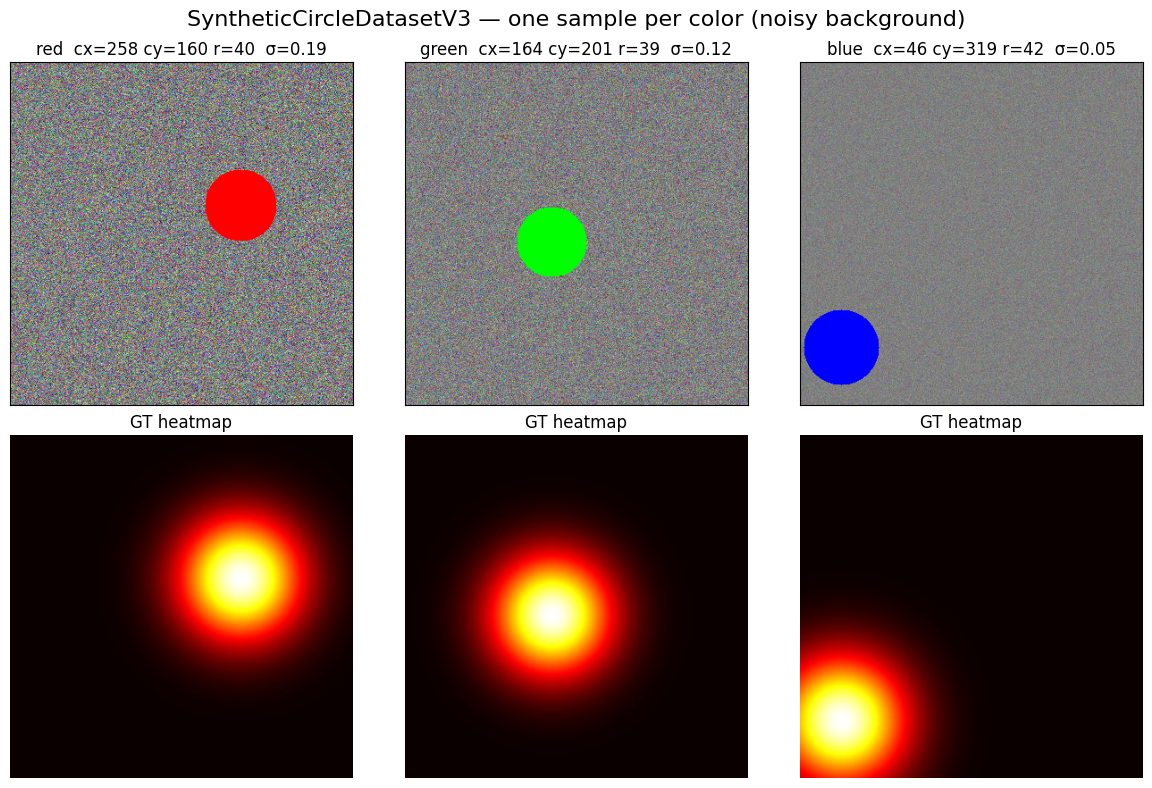

Color distribution — red:625  green:697  blue:678
Mean noise std: 0.125  range: [0.050, 0.200]


In [11]:
def make_gaussian_heatmap(h, w, cx, cy, sigma):
    xs = np.arange(w, dtype=np.float32)
    ys = np.arange(h, dtype=np.float32)
    xg, yg = np.meshgrid(xs, ys)
    return np.exp(-((xg - cx) ** 2 + (yg - cy) ** 2) / (2 * sigma ** 2)).astype(np.float32)


class SyntheticCircleDatasetV3(Dataset):
    """
    Gaussian-noise background + colored circle (red / green / blue), 384×384.
    Seed=13.  Background noise std is sampled per image from
    U[NOISE_STD_MIN, NOISE_STD_MAX], clipped to [0, 1].

    Returns:
        image   : FloatTensor [3, H, W]  in [0, 1]
        heatmap : FloatTensor [1, H, W]  Gaussian centred at circle
        meta    : dict{cx, cy, r, color, noise_std}
    """
    def __init__(self, n_samples=2000, image_size=IMAGE_SIZE,
                 r_min=9, r_max=45, sigma_factor=1.2,
                 noise_std_min=NOISE_STD_MIN, noise_std_max=NOISE_STD_MAX):
        self.n  = n_samples
        self.H  = self.W = image_size
        self.sf = sigma_factor
        rng = np.random.default_rng(SEED)
        self.radii      = rng.integers(r_min, r_max + 1, size=n_samples)
        self.cxs        = rng.integers(r_max, image_size - r_max, size=n_samples)
        self.cys        = rng.integers(r_max, image_size - r_max, size=n_samples)
        self.colors     = rng.integers(0, 3, size=n_samples)
        self.noise_stds = rng.uniform(noise_std_min, noise_std_max, size=n_samples).astype(np.float32)

    def __len__(self): return self.n

    def __getitem__(self, idx):
        H, W = self.H, self.W
        cx, cy, r = int(self.cxs[idx]), int(self.cys[idx]), int(self.radii[idx])
        color_idx  = int(self.colors[idx])
        noise_std  = float(self.noise_stds[idx])

        # Gaussian noise background clipped to [0, 1]
        img = np.clip(np.random.normal(0.5, noise_std, (H, W, 3)), 0, 1).astype(np.float32)
        # Paint circle on top
        ys, xs = np.ogrid[:H, :W]
        img[(xs - cx) ** 2 + (ys - cy) ** 2 <= r ** 2] = COLORS[color_idx]

        hm = make_gaussian_heatmap(H, W, cx, cy, self.sf * r)
        return (torch.from_numpy(img.transpose(2, 0, 1)),
                torch.from_numpy(hm).unsqueeze(0),
                {'cx': cx, 'cy': cy, 'r': r, 'color': color_idx, 'noise_std': noise_std})


ds = SyntheticCircleDatasetV3(n_samples=2000)

# Show one sample of each color
color_samples = {}
for i in range(len(ds)):
    _, _, m = ds[i]
    if m['color'] not in color_samples:
        color_samples[m['color']] = i
    if len(color_samples) == 3:
        break

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (color_idx, sample_idx) in enumerate(sorted(color_samples.items())):
    img_t, hm_t, meta = ds[sample_idx]
    axes[0, col].imshow(img_t.permute(1, 2, 0).numpy())
    axes[0, col].set_title(f"{COLOR_NAMES[color_idx]}  cx={meta['cx']} cy={meta['cy']} r={meta['r']}  σ={meta['noise_std']:.2f}")
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
    axes[1, col].imshow(hm_t.squeeze().numpy(), cmap='hot')
    axes[1, col].set_title('GT heatmap')
    axes[1, col].axis('off')

plt.suptitle('SyntheticCircleDatasetV3 — one sample per color (noisy background)', fontsize=16)
plt.tight_layout()
plt.show()

counts = np.bincount(ds.colors)
print(f'Color distribution — red:{counts[0]}  green:{counts[1]}  blue:{counts[2]}')
noise_mean = ds.noise_stds.mean()
print(f'Mean noise std: {noise_mean:.3f}  range: [{ds.noise_stds.min():.3f}, {ds.noise_stds.max():.3f}]')

## 2. Save to Disk

In [17]:
def save_dataset_to_disk(dataset, out_dir: Path) -> None:
    (out_dir / 'images').mkdir(parents=True, exist_ok=True)
    (out_dir / 'heatmaps').mkdir(parents=True, exist_ok=True)
    manifest = []
    for idx in range(len(dataset)):
        img_t, hm_t, meta = dataset[idx]
        img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        PILImage.fromarray(img_np).save(out_dir / 'images' / f'{idx:05d}.png')
        np.save(out_dir / 'heatmaps' / f'{idx:05d}.npy', hm_t.squeeze().numpy())
        manifest.append({'idx': idx, 'cx': meta['cx'], 'cy': meta['cy'],
                         'r': meta['r'], 'color': meta['color']})
        if (idx + 1) % 500 == 0:
            print(f'  {idx + 1}/{len(dataset)} saved')
    with open(out_dir / 'manifest.json', 'w') as f:
        json.dump(manifest, f)
    print(f'Saved {len(dataset)} samples to {out_dir}')


if not (DATASET_DIR / 'manifest.json').exists():
    save_dataset_to_disk(ds, DATASET_DIR)
else:
    print(f'Already on disk at {DATASET_DIR} — skipping.')

  500/2000 saved
  1000/2000 saved
  1500/2000 saved
  2000/2000 saved
Saved 2000 samples to ../data/processed/decoder_dataset_v3


## 3. Upload to HuggingFace Hub

Uploads to `Bmingg/cs280-synthetic-circles-v3`.  
Columns: `image` (PIL PNG), `cx`, `cy`, `radius`, `color` (0=red, 1=green, 2=blue).  

**Before running:** `huggingface-cli login` once in the terminal.

**Install if needed:** `pip install datasets huggingface_hub`

In [18]:
HF_REPO = 'Bmingg/cs280-synthetic-circles-v3'

# Uncomment to log in interactively
# from huggingface_hub import login; login()

def build_and_upload(manifest_path: Path, images_dir: Path, repo_id: str) -> None:
    from datasets import Dataset, Features, Image as HFImage, Value

    with open(manifest_path) as f:
        manifest = json.load(f)

    records = {
        'image':  [str(images_dir / f"{e['idx']:05d}.png") for e in manifest],
        'cx':     [e['cx']    for e in manifest],
        'cy':     [e['cy']    for e in manifest],
        'radius': [e['r']     for e in manifest],
        'color':  [e['color'] for e in manifest],   # 0=red, 1=green, 2=blue
    }
    features = Features({
        'image':  HFImage(),
        'cx':     Value('int32'),
        'cy':     Value('int32'),
        'radius': Value('int32'),
        'color':  Value('int8'),
    })
    hf_ds = Dataset.from_dict(records, features=features)
    print(hf_ds)
    print(f'Pushing to {repo_id} ...')
    hf_ds.push_to_hub(repo_id, private=False)
    print(f'Done — https://huggingface.co/datasets/{repo_id}')


if (DATASET_DIR / 'manifest.json').exists():
    build_and_upload(DATASET_DIR / 'manifest.json', DATASET_DIR / 'images', HF_REPO)
else:
    print('Save the dataset to disk first (Section 2).')

Dataset({
    features: ['image', 'cx', 'cy', 'radius', 'color'],
    num_rows: 2000
})
Pushing to Bmingg/cs280-synthetic-circles-v3 ...


Uploading the dataset shards:   0%|          | 0/2 [00:00<?, ? shards/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done — https://huggingface.co/datasets/Bmingg/cs280-synthetic-circles-v3


## 4. Load from HuggingFace Hub

Once uploaded, load from HF in any environment (Mac, Kaggle, Colab) without saving locally.  
Color label: 0=red · 1=green · 2=blue.

In [19]:
from datasets import load_dataset

hf_ds = load_dataset('Bmingg/cs280-synthetic-circles-v3', split='train')
print(hf_ds)
print(f'Columns: {hf_ds.column_names}')
print(f'First sample — cx:{hf_ds[0]["cx"]}  cy:{hf_ds[0]["cy"]}  '
      f'radius:{hf_ds[0]["radius"]}  color:{COLOR_NAMES[hf_ds[0]["color"]]}')

README.md:   0%|          | 0.00/406 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/403M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/405M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'cx', 'cy', 'radius', 'color'],
    num_rows: 2000
})
Columns: ['image', 'cx', 'cy', 'radius', 'color']
First sample — cx:46  cy:319  radius:42  color:blue


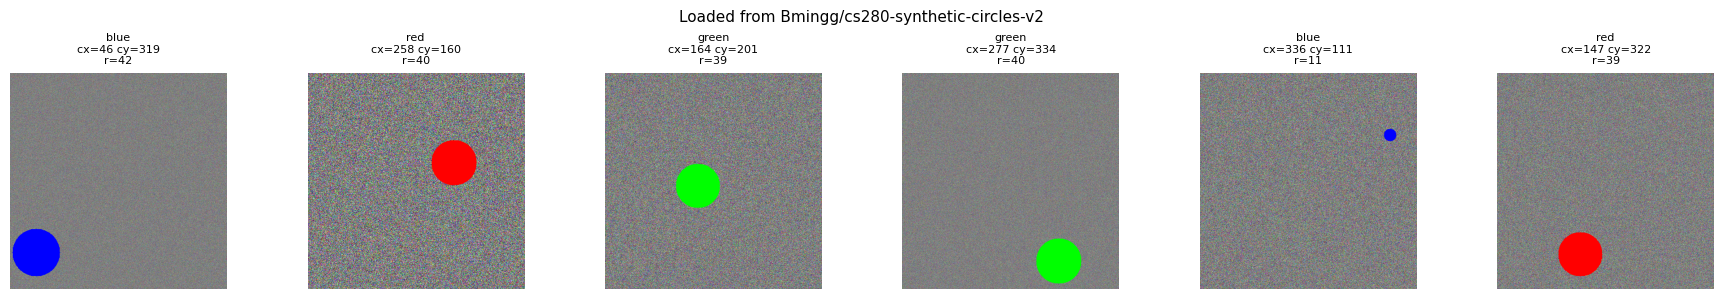

In [20]:
# Visualise a few samples loaded from HF
N_SHOW = 6
fig, axes = plt.subplots(1, N_SHOW, figsize=(3 * N_SHOW, 3))

for i, ax in enumerate(axes):
    row = hf_ds[i]
    ax.imshow(row['image'])   # HF returns PIL Image
    ax.set_title(
        f"{COLOR_NAMES[row['color']]}\n"
        f"cx={row['cx']} cy={row['cy']}\nr={row['radius']}",
        fontsize=8,
    )
    ax.axis('off')

plt.suptitle('Loaded from Bmingg/cs280-synthetic-circles-v2', fontsize=11)
plt.tight_layout()
plt.show()

## 5. PyTorch Dataset Wrapper (for training)

Wraps the HF dataset so it can be used directly in a `DataLoader`.  
Regenerates Gaussian heatmaps on the fly from `(cx, cy, radius)`.

In [ ]:
class HFCircleDataset(Dataset):
    """
    Wraps the HF dataset for use in a PyTorch DataLoader.

    Returns:
        image   : FloatTensor [3, H, W]  in [0, 1]
        heatmap : FloatTensor [1, H, W]  Gaussian centred at circle
        meta    : dict{cx, cy, r, color}
    """
    def __init__(self, hf_dataset, image_size=IMAGE_SIZE, sigma_factor=1.5):
        self.ds  = hf_dataset
        self.H   = self.W = image_size
        self.sf  = sigma_factor

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        cx, cy, r, color = row['cx'], row['cy'], row['radius'], row['color']

        # PIL Image → float tensor [3,H,W]
        img_np  = np.array(row['image'].resize((self.H, self.W))).astype(np.float32) / 255.0
        image_t = torch.from_numpy(img_np.transpose(2, 0, 1))

        hm      = make_gaussian_heatmap(self.H, self.W, cx, cy, self.sf * r)
        heatmap_t = torch.from_numpy(hm).unsqueeze(0)

        return image_t, heatmap_t, {'cx': cx, 'cy': cy, 'r': r, 'color': color}


# Quick shape check
torch_ds = HFCircleDataset(hf_ds)
img_t, hm_t, meta = torch_ds[0]
print(f'image: {img_t.shape}  heatmap: {hm_t.shape}  color: {COLOR_NAMES[meta["color"]]}')